<a href="https://colab.research.google.com/github/alexandraszkoda/GB885-Final-Project-Szkoda-A/blob/main/RUSH_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RUSH Sportswear — 2020–2021 US Sales Analysis

**Analyst:** A Szkoda  
**Course:** GB885 — Final Project  
**Prepared for:** VP of US Sales

---

## 1. Business Context and Objective

RUSH is a global sportswear and footwear brand. The company stores its raw US sales data in three
tables — `TABLE_SALES`, `TABLE_RETAILER`, and `TABLE_PRODUCTS`. The data is *raw*: it has not been
cleaned and is known to contain errors.

The VP of US Sales has asked for two things:

**A. Direct answers to four business questions**

1. What product category had the highest sales (in dollars) in 2021? How much did it sell?
2. What state had the highest sales (in dollars) of **women's** products in 2021, and how much?
3. What state had the highest sales (in dollars) of **men's** products in 2021, and how much?
4. What retailer purchased the most units in 2021? In 2020?

**B. Independent analysis** — trends and insights in seasonality, retailers, locations, and sales
methods that help leadership understand the market and find growth opportunities.

## 2. Analysis Roadmap

| Section | Purpose |
|---|---|
| 3. Setup | Imports, display options, file paths |
| 4. Data Acquisition | Load the three raw tables |
| 5. Data Inspection | Structure, types, missing values, duplicates, value ranges |
| 6. Data Cleaning | Fix every defect found in Section 5, with rationale |
| 7. Referential Integrity | Validate the joins before merging |
| 8. Analysis Dataset | Merge to one order-level table and derive metrics |
| 9. VP's Business Questions | Q1–Q4, answered and charted |
| 10. Insights & Trends | Growth drivers, channel mix, seasonality, concentration, geography |
| 11. Findings & Recommendations | The story for senior leadership |
| 12. Appendix | Sensitivity check on the ambiguous retailer key |

### Key metric definition

`TABLE_SALES` stores price and quantity but **not** revenue, so total sales dollars are derived:

$$\text{Total Sales} = \text{PRICE\_PER\_UNIT} \times \text{UNITS\_SOLD}$$
$$\text{Operating Profit} = \text{Total Sales} \times \text{OPERATING\_MARGIN}$$


---
## 3. Setup

In [1]:
# Standard library
from pathlib import Path

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# Consistent chart styling (RUSH brand: deep navy + a single warm accent)
plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})
NAVY, ACCENT, GREY = "#12324F", "#E4572E", "#9AA5AD"
PALETTE = [NAVY, ACCENT, "#3F7CAC", "#95AFBA", "#C4CDD3", "#6E8898"]

def money(x, _=None):
    """Format an axis tick as compact dollars (e.g. 22.7M)."""
    if abs(x) >= 1e6:
        return f"${x/1e6:,.1f}M"
    if abs(x) >= 1e3:
        return f"${x/1e3:,.0f}K"
    return f"${x:,.0f}"

def save(fig, name):
    """Save a figure to figures/ so the deck and the notebook stay in sync."""
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}.png", dpi=160, bbox_inches="tight")

print("Environment ready — pandas", pd.__version__)

Environment ready — pandas 2.2.2


---
## 4. Data Acquisition

Three raw extracts are loaded from `data/`. Two things to be careful about here:

* `TABLE_PRODUCTS_885.csv` is **pipe-delimited** (`|`), not comma-delimited. Reading it with the
  default separator collapses it into a single column.
* All three files are saved with a UTF-8 **byte-order mark**, so `encoding="utf-8-sig"` is used to
  stop the first column name from being read as `ï»¿PRODUCT_ID`.

Every column is loaded as text first. Converting types *after* inspection means a bad value fails
loudly in cleaning instead of being silently coerced to `NaN` on import.

In [3]:
# Upload the data
from google.colab import files; files.upload()   # select all 3 CSVs
DATA_DIR = Path(".")

Saving TABLE_PRODUCTS_885.csv to TABLE_PRODUCTS_885.csv
Saving TABLE_RETAILER_885.csv to TABLE_RETAILER_885.csv
Saving TABLE_SALES_885.csv to TABLE_SALES_885.csv


In [4]:
# Write figures and exports to the project root, not to whatever folder the notebook sits in
PROJECT_ROOT = DATA_DIR.parent if DATA_DIR.name == "data" else DATA_DIR
FIG_DIR = PROJECT_ROOT / "figures"
OUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)
print("Reading from :", DATA_DIR.resolve())
print("Writing to   :", PROJECT_ROOT.resolve())

sales_raw = pd.read_csv(DATA_DIR / "TABLE_SALES_885.csv", encoding="utf-8-sig", dtype=str)
retailer_raw = pd.read_csv(DATA_DIR / "TABLE_RETAILER_885.csv", encoding="utf-8-sig", dtype=str)
products_raw = pd.read_csv(DATA_DIR / "TABLE_PRODUCTS_885.csv", encoding="utf-8-sig",
                           dtype=str, sep="|")

for name, df in [("SALES", sales_raw), ("RETAILER", retailer_raw), ("PRODUCTS", products_raw)]:
    print(f"{name:<9} {df.shape[0]:>6,} rows x {df.shape[1]} columns   {list(df.columns)}")

Reading from : /content
Writing to   : /content
SALES      9,648 rows x 11 columns   ['ORDER_ID', 'RETAILER_ID', 'INVOICE_DATE', 'MONTH', 'DAY', 'YEAR', 'PRODUCT_ID', 'PRICE_PER_UNIT', 'UNITS_SOLD', 'OPERATING_MARGIN', 'SALES_METHOD']
RETAILER     110 rows x 5 columns   ['RETAILER_ID', 'RETAILER', 'REGION', 'STATE', 'CITY']
PRODUCTS       6 rows x 2 columns   ['PRODUCT_ID', 'PRODUCT_NAME']


In [5]:
# First look at each table
display(sales_raw.head(3))
display(retailer_raw.head(3))
display(products_raw)

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
0,0001,A00MOHCO,1/1/2020,01,01,2020,020,50,1200,0.5,In-store
1,0007,A00MOHCO,1/7/2020,01,07,2020,020,50,1250,0.5,In-store
2,0013,A00MOHCO,1/25/2020,01,25,2020,020,50,1220,0.5,Outlet


,RETAILER_ID,RETAILER,REGION,STATE,CITY
0,A00MOHCO,Amazon,Midwest,Ohio,Columbus
1,A00NMAPO,Amazon,Northeast,Maine,Portland
2,A00NMABO,Amazon,Northeast,Massachusetts,Boston


,PRODUCT_ID,PRODUCT_NAME
0,020,Men's Street Footwear
1,030,Men's Athletic Footwear
2,120,Women's Street Footwear
3,130,Women's Athletic Footwear
4,040,Men's Apparel
5,140,Women's Apparel


---
## 5. Data Inspection

The goal of this section is to find every defect *before* touching the data, so the cleaning steps
in Section 6 are deliberate rather than reactive. Six checks are run against `TABLE_SALES`, which
holds all the numeric measures and is where errors are most costly.

### 5.1 Structure, missing values, and duplicates

In [6]:
def profile(df, name):
    """Compact profile: dtype, missing count, distinct count, and a sample value per column."""
    out = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "distinct": df.nunique(dropna=True),
        "example": [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
    })
    print(f"--- {name}: {len(df):,} rows | exact duplicate rows: {df.duplicated().sum()} ---")
    return out

display(profile(sales_raw, "TABLE_SALES"))
display(profile(retailer_raw, "TABLE_RETAILER"))
display(profile(products_raw, "TABLE_PRODUCTS"))

--- TABLE_SALES: 9,648 rows | exact duplicate rows: 0 ---


,dtype,missing,distinct,example
ORDER_ID,object,0,9648,0001
RETAILER_ID,object,0,107,A00MOHCO
INVOICE_DATE,object,0,724,1/1/2020
MONTH,object,0,12,01
DAY,object,0,31,01
YEAR,object,0,2,2020
PRODUCT_ID,object,0,6,020
PRICE_PER_UNIT,object,2,95,50
UNITS_SOLD,object,0,362,1200
OPERATING_MARGIN,object,0,66,0.5


--- TABLE_RETAILER: 110 rows | exact duplicate rows: 0 ---


,dtype,missing,distinct,example
RETAILER_ID,object,0,106,A00MOHCO
RETAILER,object,0,6,Amazon
REGION,object,0,5,Midwest
STATE,object,0,50,Ohio
CITY,object,0,52,Columbus


--- TABLE_PRODUCTS: 6 rows | exact duplicate rows: 0 ---


,dtype,missing,distinct,example
PRODUCT_ID,object,0,6,020
PRODUCT_NAME,object,0,6,Men's Street Footwear


**Observations**

* `TABLE_SALES` carries three columns the data dictionary does not document — `MONTH`, `DAY`, and
  `YEAR`. They are redundant with `INVOICE_DATE` and are verified against it in 5.3.
* `PRICE_PER_UNIT` has 2 missing values.
* No exact duplicate rows in any table.

### 5.2 Primary and foreign key integrity

In [7]:
print("SALES.ORDER_ID unique?          ", sales_raw["ORDER_ID"].is_unique)
print("PRODUCTS.PRODUCT_ID unique?     ", products_raw["PRODUCT_ID"].is_unique)
print("RETAILER.RETAILER_ID unique?    ", retailer_raw["RETAILER_ID"].is_unique)

dupe_ids = retailer_raw.loc[retailer_raw["RETAILER_ID"].duplicated(keep=False)]
print(f"\nRETAILER_ID values used by more than one location: {dupe_ids['RETAILER_ID'].nunique()}")
display(dupe_ids.sort_values("RETAILER_ID"))

orphans = set(sales_raw["RETAILER_ID"]) - set(retailer_raw["RETAILER_ID"])
print("RETAILER_IDs in SALES with no matching row in RETAILER:", orphans)
display(sales_raw[sales_raw["RETAILER_ID"].isin(orphans)])

print("PRODUCT_IDs in SALES with no match in PRODUCTS:",
      set(sales_raw["PRODUCT_ID"]) - set(products_raw["PRODUCT_ID"]))

SALES.ORDER_ID unique?           True
PRODUCTS.PRODUCT_ID unique?      True
RETAILER.RETAILER_ID unique?     False

RETAILER_ID values used by more than one location: 4


,RETAILER_ID,RETAILER,REGION,STATE,CITY
63,S00NNENE,Sports Direct,Northeast,New Jersey,Newark
64,S00NNENE,Sports Direct,Northeast,New York,New York
81,W00SARLI,Walmart,South,Arkansas,Little Rock
97,W00SARLI,West Gear,South,Arkansas,Little Rock
84,W00SFLOR,Walmart,Southeast,Florida,Orlando
102,W00SFLOR,West Gear,Southeast,Florida,Orlando
83,W00STEHO,Walmart,South,Texas,Houston
100,W00STEHO,West Gear,South,Texas,Houston


RETAILER_IDs in SALES with no matching row in RETAILER: {'999999999'}


,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
1446,8668,999999999,7/23/2021,07,23,2021,020,60,298,0.42,Outlet


PRODUCT_IDs in SALES with no match in PRODUCTS: set()


**Finding — the retailer key is not unique.** `RETAILER_ID` is a constructed code:
first letter of the retailer + `00` + region initial + first two letters of the state + first two
letters of the city. That scheme collides whenever two retailers share a first letter or two
locations share letter pairs:

| ID | Location A | Location B | Cause |
|---|---|---|---|
| `S00NNENE` | Sports Direct — Newark, NJ | Sports Direct — New York, NY | *New Jersey/New York* and *Newark/New York* both shorten to `NE` |
| `W00SARLI` | **Wal**mart — Little Rock, AR | **We**st Gear — Little Rock, AR | both retailers start with `W` |
| `W00SFLOR` | Walmart — Orlando, FL | West Gear — Orlando, FL | same |
| `W00STEHO` | Walmart — Houston, TX | West Gear — Houston, TX | same |

This matters: a naive `merge` on a duplicated key **duplicates every matching sales row**, which
would silently inflate revenue. It is handled in Section 7 and stress-tested in the Appendix.

**Finding — one orphan foreign key.** Order `8668` carries `RETAILER_ID = 999999999`, a placeholder
that matches no retailer. It is a single order and is retained for company-level totals but cannot
be attributed to a location.

### 5.3 Dates

In [8]:
dates = pd.to_datetime(sales_raw["INVOICE_DATE"], format="%m/%d/%Y", errors="coerce")
print("Dates that fail to parse as MM/DD/YYYY:", dates.isna().sum())
print("Date range:", dates.min().date(), "to", dates.max().date())

# The undocumented MONTH/DAY/YEAR columns should agree with INVOICE_DATE
mismatch = (
    (dates.dt.month != sales_raw["MONTH"].astype(int))
    | (dates.dt.day != sales_raw["DAY"].astype(int))
    | (dates.dt.year != sales_raw["YEAR"].astype(int))
)
print("Rows where MONTH/DAY/YEAR disagree with INVOICE_DATE:", mismatch.sum())

Dates that fail to parse as MM/DD/YYYY: 0
Date range: 2020-01-01 to 2021-12-31
Rows where MONTH/DAY/YEAR disagree with INVOICE_DATE: 0


No unparseable dates and no disagreement between `INVOICE_DATE` and the redundant parts, so
`INVOICE_DATE` is trusted as the single source of truth and `MONTH`/`DAY`/`YEAR` are dropped.

### 5.4 Categorical values

In [9]:
for col in ["SALES_METHOD", "PRODUCT_ID"]:
    print(f"{col}:")
    print(sales_raw[col].value_counts(dropna=False).to_string(), "\n")

for col in ["RETAILER", "REGION"]:
    print(f"{col}: {sorted(retailer_raw[col].unique())}")
print("STATE:", retailer_raw['STATE'].nunique(), "distinct | CITY:", retailer_raw['CITY'].nunique())

SALES_METHOD:
SALES_METHOD
Online      4889
Outlet      2999
In-store    1740
Ootlet        20 

PRODUCT_ID:
PRODUCT_ID
020    1610
030    1610
120    1608
140    1608
040    1606
130    1606 

RETAILER: ['Amazon', 'Foot Locker', "Kohl's", 'Sports Direct', 'Walmart', 'West Gear']
REGION: ['Midwest', 'Northeast', 'South', 'Southeast', 'West']
STATE: 50 distinct | CITY: 52


**Finding — `SALES_METHOD` contains a misspelling.** The dictionary defines three methods
(`In-store`, `Outlet`, `Online`) but the data contains a fourth value, **`Ootlet`**. Left as-is it
would split the Outlet channel across two categories and understate it.

### 5.5 Numeric ranges and impossible values

In [10]:
num_cols = ["PRICE_PER_UNIT", "UNITS_SOLD", "OPERATING_MARGIN"]
numeric = sales_raw[num_cols].apply(pd.to_numeric, errors="coerce")

print("Values that are not numeric at all:")
for c in num_cols:
    bad = sales_raw.loc[numeric[c].isna() & sales_raw[c].notna(), c]
    print(f"  {c}: {bad.value_counts().to_dict() or 'none'}")

display(numeric.describe().T[["count", "mean", "std", "min", "50%", "max"]])

Values that are not numeric at all:
  PRICE_PER_UNIT: none
  UNITS_SOLD: {'***': 2}
  OPERATING_MARGIN: none


,count,mean,std,min,50%,max
PRICE_PER_UNIT,"9,646.00",55.58,"1,017.82",7.00,45.00,"99,999.00"
UNITS_SOLD,"9,646.00",256.94,214.27,0.00,176.00,"1,275.00"
OPERATING_MARGIN,"9,648.00",0.42,0.10,0.10,0.41,0.80


In [11]:
# Flag rows that are numerically implausible for a footwear/apparel order
print("PRICE_PER_UNIT above $500 (retail price of a shoe should never be this):")
display(sales_raw[numeric["PRICE_PER_UNIT"] > 500])

print("\nUNITS_SOLD equal to zero:")
display(sales_raw[numeric["UNITS_SOLD"] == 0])

print("\nOPERATING_MARGIN outside 0-1:", ((numeric["OPERATING_MARGIN"] < 0) |
                                          (numeric["OPERATING_MARGIN"] > 1)).sum())

PRICE_PER_UNIT above $500 (retail price of a shoe should never be this):


,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
423,2536,F00NNEMA,5/23/2021,05,23,2021,020,99999,520,0.4,Online



UNITS_SOLD equal to zero:


,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
6603,1020,F00SVIRI,6/5/2021,06,05,2021,130,35,0,0.4,Outlet
6604,1026,F00SVIRI,6/11/2021,06,11,2021,130,30,0,0.4,Outlet
7250,4908,S00MMIDE,6/5/2021,06,05,2021,130,33,0,0.55,Online
7251,4914,S00MMIDE,6/11/2021,06,11,2021,130,27,0,0.53,Online



OPERATING_MARGIN outside 0-1: 0


### 5.6 Data quality issues — summary

| # | Table | Issue | Rows | Treatment (Section 6) |
|---|---|---|---|---|
| 1 | SALES | `SALES_METHOD` misspelled `Ootlet` | 20 | Recode to `Outlet` |
| 2 | SALES | `UNITS_SOLD` contains the literal string `***` | 2 | Convert to missing, then impute |
| 3 | SALES | `PRICE_PER_UNIT` missing | 2 | Impute |
| 4 | SALES | `PRICE_PER_UNIT` = `99999` — a sentinel, not a price | 1 | Treat as missing, then impute |
| 5 | SALES | `UNITS_SOLD` = 0 on priced orders | 4 | Retain and flag — contributes $0 revenue |
| 6 | SALES | Orphan `RETAILER_ID` `999999999` | 1 | Retain; location shown as *Unknown* |
| 7 | SALES | Undocumented `MONTH`/`DAY`/`YEAR` columns | all | Verified against `INVOICE_DATE`, then dropped |
| 8 | RETAILER | `RETAILER_ID` is not unique — 4 collisions | 8 | De-duplicate the dimension before joining (Section 7) |
| 9 | PRODUCTS | Pipe-delimited file, BOM-encoded | file | Handled at import |

Issue #4 is the one that would have done real damage: a single order of 520 units priced at
`$99,999` would have added **$52M** of phantom revenue to a $96M year — a 54% overstatement,
and it would have put New Hampshire at the top of two of the VP's four questions.

---
## 6. Data Cleaning

Each fix below is applied to a copy, `sales`, so the raw extract stays available for comparison.

### 6.1 Type conversion

In [12]:
sales = sales_raw.copy()

# Dates: parse once, then drop the redundant undocumented parts (verified equal in 5.3)
sales["INVOICE_DATE"] = pd.to_datetime(sales["INVOICE_DATE"], format="%m/%d/%Y")
sales = sales.drop(columns=["MONTH", "DAY", "YEAR"])

# Numerics: '***' and other non-numeric text become NaN and are imputed in 6.3
for col in ["PRICE_PER_UNIT", "UNITS_SOLD", "OPERATING_MARGIN"]:
    sales[col] = pd.to_numeric(sales[col], errors="coerce")

# Identifiers stay as strings — PRODUCT_ID '020' must not become the integer 20
for col in ["ORDER_ID", "RETAILER_ID", "PRODUCT_ID"]:
    sales[col] = sales[col].str.strip()

sales["SALES_METHOD"] = sales["SALES_METHOD"].str.strip()
sales.dtypes

,0
ORDER_ID,object
RETAILER_ID,object
INVOICE_DATE,datetime64[ns]
PRODUCT_ID,object
PRICE_PER_UNIT,float64
UNITS_SOLD,float64
OPERATING_MARGIN,float64
SALES_METHOD,object


### 6.2 Standardise the sales method

In [13]:
before = sales["SALES_METHOD"].value_counts()
sales["SALES_METHOD"] = sales["SALES_METHOD"].replace({"Ootlet": "Outlet"})
after = sales["SALES_METHOD"].value_counts()

pd.DataFrame({"before": before, "after": after}).fillna(0).astype(int)

,before,after
SALES_METHOD,,
In-store,1740,1740
Online,4889,4889
Ootlet,20,0
Outlet,2999,3019


### 6.3 Impossible values and imputation

`PRICE_PER_UNIT = 99999` is a data-entry sentinel, not a price — the next highest price in the
dataset is $110. It is converted to missing and imputed alongside the genuinely missing values.

**Imputation rule:** each missing measure is filled with the **median of the same product, at the
same retailer location, in the same year**, which preserves the local price/volume regime. Where
that group is too sparse, the fallback is the product-level median.

Five values are imputed out of 28,944 measures (0.02%), so the effect on any aggregate is
negligible — but the alternative of dropping the rows would silently discard real orders.

In [14]:
PRICE_CEILING = 500  # no RUSH SKU in this catalogue sells anywhere near this
sales["WAS_IMPUTED"] = False

impossible = sales["PRICE_PER_UNIT"] > PRICE_CEILING
print(f"Sentinel prices converted to missing: {impossible.sum()}")
sales.loc[impossible, "PRICE_PER_UNIT"] = np.nan

sales["WAS_IMPUTED"] = sales[["PRICE_PER_UNIT", "UNITS_SOLD"]].isna().any(axis=1)
print(f"Rows requiring imputation: {sales['WAS_IMPUTED'].sum()}")

year = sales["INVOICE_DATE"].dt.year
for col in ["PRICE_PER_UNIT", "UNITS_SOLD"]:
    local = sales.groupby(["PRODUCT_ID", "RETAILER_ID", year])[col].transform("median")
    product = sales.groupby("PRODUCT_ID")[col].transform("median")
    sales[col] = sales[col].fillna(local).fillna(product)

sales["UNITS_SOLD"] = sales["UNITS_SOLD"].round().astype(int)
print("Remaining missing values in SALES:", int(sales.isna().sum().sum()))
display(sales.loc[sales["WAS_IMPUTED"], ["ORDER_ID", "RETAILER_ID", "PRODUCT_ID",
                                         "PRICE_PER_UNIT", "UNITS_SOLD"]])

Sentinel prices converted to missing: 1
Rows requiring imputation: 5
Remaining missing values in SALES: 0


,ORDER_ID,RETAILER_ID,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD
98,0591,A00NVEBU,020,60.00,525
99,0597,A00NVEBU,020,60.00,525
423,2536,F00NNEMA,020,50.00,520
1012,6064,S00SALBI,020,51.00,165
1439,8626,W00MIODE,020,29.00,228


### 6.4 Zero-unit orders

Four orders record a valid price but zero units. They look like cancelled or voided orders rather
than corrupted values. They are kept — they contribute $0 and therefore cannot distort revenue —
but they are flagged so order-count metrics can exclude them if needed.

In [15]:
sales["IS_ZERO_UNIT"] = sales["UNITS_SOLD"] == 0
print(f"Zero-unit orders flagged: {sales['IS_ZERO_UNIT'].sum()}")
display(sales[sales["IS_ZERO_UNIT"]])

Zero-unit orders flagged: 4


,ORDER_ID,RETAILER_ID,INVOICE_DATE,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,WAS_IMPUTED,IS_ZERO_UNIT
6603,1020,F00SVIRI,2021-06-05,130,35.00,0,0.40,Outlet,False,True
6604,1026,F00SVIRI,2021-06-11,130,30.00,0,0.40,Outlet,False,True
7250,4908,S00MMIDE,2021-06-05,130,33.00,0,0.55,Online,False,True
7251,4914,S00MMIDE,2021-06-11,130,27.00,0,0.53,Online,False,True


### 6.5 Clean the dimension tables

In [16]:
retailer = retailer_raw.copy()
products = products_raw.copy()

for df in (retailer, products):
    for c in df.columns:
        df[c] = df[c].str.strip()

# Split the long product name into the two dimensions leadership actually asks about
products["GENDER"] = np.where(products["PRODUCT_NAME"].str.startswith("Men"), "Men", "Women")
products["CATEGORY"] = np.where(products["PRODUCT_NAME"].str.contains("Footwear"),
                                "Footwear", "Apparel")
display(products)

,PRODUCT_ID,PRODUCT_NAME,GENDER,CATEGORY
0,020,Men's Street Footwear,Men,Footwear
1,030,Men's Athletic Footwear,Men,Footwear
2,120,Women's Street Footwear,Women,Footwear
3,130,Women's Athletic Footwear,Women,Footwear
4,040,Men's Apparel,Men,Apparel
5,140,Women's Apparel,Women,Apparel


---
## 7. Referential Integrity Before the Join

Because `RETAILER_ID` is duplicated for four locations, joining directly would fan out 623 sales
rows into 1,246. The dimension is therefore de-duplicated to one row per key **before** the merge,
and row counts are asserted afterwards so the problem cannot reappear unnoticed.

The Appendix quantifies the ambiguity: 46,016 units and $2.26M of 2021 revenue sit under a key that
could belong to either Walmart or West Gear. That is 2.4% of 2021 revenue, and — importantly — it
does not change the answer to any of the VP's questions.

In [17]:
affected = sales["RETAILER_ID"].isin(dupe_ids["RETAILER_ID"]).sum()
print(f"Sales rows attached to an ambiguous retailer key: {affected:,}")
print(f"Rows a naive merge would produce instead: {affected * 2:,}")

retailer_dim = retailer.drop_duplicates("RETAILER_ID", keep="first").copy()
print(f"\nRETAILER rows: {len(retailer)} -> {len(retailer_dim)} after de-duplication")
print("Key now unique?", retailer_dim["RETAILER_ID"].is_unique)

Sales rows attached to an ambiguous retailer key: 623
Rows a naive merge would produce instead: 1,246

RETAILER rows: 110 -> 106 after de-duplication
Key now unique? True


---
## 8. Build the Analysis Dataset

One order-level table, `df`, with the derived measures the analysis needs. `left` joins preserve
every order — including the orphan `999999999` — so nothing disappears silently.

In [18]:
df = (sales
      .merge(retailer_dim, on="RETAILER_ID", how="left", validate="many_to_one")
      .merge(products, on="PRODUCT_ID", how="left", validate="many_to_one"))

assert len(df) == len(sales), "Join changed the row count — the key is not unique"

# Unattributable location, kept visible rather than dropped
for col in ["RETAILER", "REGION", "STATE", "CITY"]:
    df[col] = df[col].fillna("Unknown")

# Derived measures
df["TOTAL_SALES"] = df["PRICE_PER_UNIT"] * df["UNITS_SOLD"]
df["OPERATING_PROFIT"] = df["TOTAL_SALES"] * df["OPERATING_MARGIN"]
df["YEAR"] = df["INVOICE_DATE"].dt.year
df["MONTH"] = df["INVOICE_DATE"].dt.month
df["MONTH_NAME"] = df["INVOICE_DATE"].dt.strftime("%b")
df["QUARTER"] = df["INVOICE_DATE"].dt.to_period("Q").astype(str)

print(f"Analysis dataset: {len(df):,} orders x {df.shape[1]} columns")
print(f"Total revenue 2020-2021: ${df['TOTAL_SALES'].sum():,.0f}")
display(df.head(3))

Analysis dataset: 9,648 orders x 23 columns
Total revenue 2020-2021: $120,167,328


,ORDER_ID,RETAILER_ID,INVOICE_DATE,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,WAS_IMPUTED,IS_ZERO_UNIT,RETAILER,REGION,STATE,CITY,PRODUCT_NAME,GENDER,CATEGORY,TOTAL_SALES,OPERATING_PROFIT,YEAR,MONTH,MONTH_NAME,QUARTER
0,0001,A00MOHCO,2020-01-01,020,50.00,1200,0.50,In-store,False,False,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear,Men,Footwear,"60,000.00","30,000.00",2020,1,Jan,2020Q1
1,0007,A00MOHCO,2020-01-07,020,50.00,1250,0.50,In-store,False,False,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear,Men,Footwear,"62,500.00","31,250.00",2020,1,Jan,2020Q1
2,0013,A00MOHCO,2020-01-25,020,50.00,1220,0.50,Outlet,False,False,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear,Men,Footwear,"61,000.00","30,500.00",2020,1,Jan,2020Q1


In [19]:
# Company-level scorecard — the frame of reference for everything that follows
scorecard = (df.groupby("YEAR")
               .agg(orders=("ORDER_ID", "count"),
                    units=("UNITS_SOLD", "sum"),
                    revenue=("TOTAL_SALES", "sum"),
                    profit=("OPERATING_PROFIT", "sum"),
                    retailers=("RETAILER", "nunique"),
                    states=("STATE", "nunique")))
scorecard["avg_selling_price"] = scorecard["revenue"] / scorecard["units"]
scorecard["margin_%"] = 100 * scorecard["profit"] / scorecard["revenue"]
scorecard

,orders,units,revenue,profit,retailers,states,avg_selling_price,margin_%
YEAR,,,,,,,,
2020,1302,462349,"24,237,325.00","9,015,505.08",4,22,52.42,37.20
2021,8346,2016524,"95,930,003.00","38,209,766.85",7,51,47.57,39.83


---
## 9. The VP's Business Questions

All four are answered on 2021 (and 2020 where asked), using the cleaned dataset.

### Q1 — Which product category had the highest sales in 2021, and how much?

In [20]:
df_2021 = df[df["YEAR"] == 2021]

q1 = (df_2021.groupby("PRODUCT_NAME")
             .agg(revenue=("TOTAL_SALES", "sum"), units=("UNITS_SOLD", "sum"))
             .sort_values("revenue", ascending=False))
q1["share_%"] = 100 * q1["revenue"] / q1["revenue"].sum()
display(q1)

top = q1.index[0]
print(f"\nANSWER Q1: {top} — ${q1.loc[top, 'revenue']:,.0f} "
      f"({q1.loc[top, 'share_%']:.1f}% of 2021 revenue, {q1.loc[top, 'units']:,.0f} units)")

,revenue,units,share_%
PRODUCT_NAME,,,
Men's Street Footwear,"22,690,427.00",494146,23.65
Women's Apparel,"19,178,278.00",353619,19.99
Men's Athletic Footwear,"16,339,593.00",353766,17.03
Women's Street Footwear,"13,535,783.00",316478,14.11
Men's Apparel,"13,025,293.00",245456,13.58
Women's Athletic Footwear,"11,160,629.00",253059,11.63



ANSWER Q1: Men's Street Footwear — $22,690,427 (23.7% of 2021 revenue, 494,146 units)


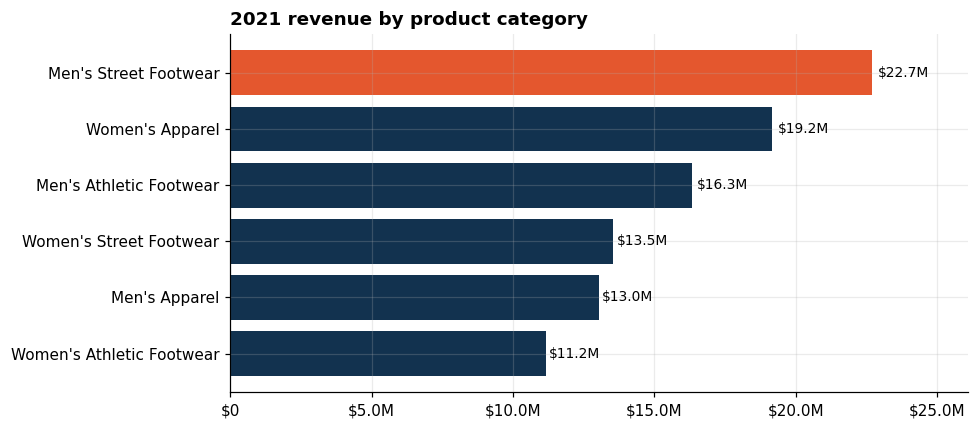

In [21]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(q1.index[::-1], q1["revenue"][::-1],
               color=[NAVY if p != top else ACCENT for p in q1.index[::-1]])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money))
ax.set_title("2021 revenue by product category", fontweight="bold", loc="left")
ax.set_xlabel("")
for b, v in zip(bars, q1["revenue"][::-1]):
    ax.text(v * 1.01, b.get_y() + b.get_height() / 2, f"${v/1e6:,.1f}M", va="center", fontsize=9)
ax.set_xlim(0, q1["revenue"].max() * 1.15)
save(fig, "q1_product_revenue"); plt.show()

### Q2 — Which state had the highest sales of women's products in 2021?

In [22]:
def top_state(data, gender):
    """Rank states by revenue for one gender segment."""
    out = (data[data["GENDER"] == gender]
           .groupby("STATE")
           .agg(revenue=("TOTAL_SALES", "sum"), units=("UNITS_SOLD", "sum"))
           .sort_values("revenue", ascending=False))
    return out

q2 = top_state(df_2021, "Women")
display(q2.head(10))
print(f"\nANSWER Q2: {q2.index[0]} — ${q2.iloc[0]['revenue']:,.0f} in women's products in 2021")

,revenue,units
STATE,,
Maine,"2,176,301.00",37697
Delaware,"2,023,575.00",41665
New Hampshire,"1,916,400.00",38690
Arizona,"1,798,900.00",30465
Missouri,"1,771,992.00",26790
Illinois,"1,743,277.00",35517
Virginia,"1,719,886.00",37076
Nebraska,"1,712,680.00",33038
Connecticut,"1,600,156.00",30469



ANSWER Q2: Maine — $2,176,301 in women's products in 2021


### Q3 — Which state had the highest sales of men's products in 2021?

In [23]:
q3 = top_state(df_2021, "Men")
display(q3.head(10))
print(f"\nANSWER Q3: {q3.index[0]} — ${q3.iloc[0]['revenue']:,.0f} in men's products in 2021")

,revenue,units
STATE,,
Delaware,"2,334,300.00",45305
Arizona,"2,261,025.00",37850
New Hampshire,"2,234,600.00",46305
Maine,"2,217,190.00",40376
Illinois,"2,093,438.00",40426
Missouri,"1,951,530.00",31098
Connecticut,"1,926,568.00",35077
New York,"1,847,069.00",45586
Nebraska,"1,718,726.00",36501



ANSWER Q3: Delaware — $2,334,300 in men's products in 2021


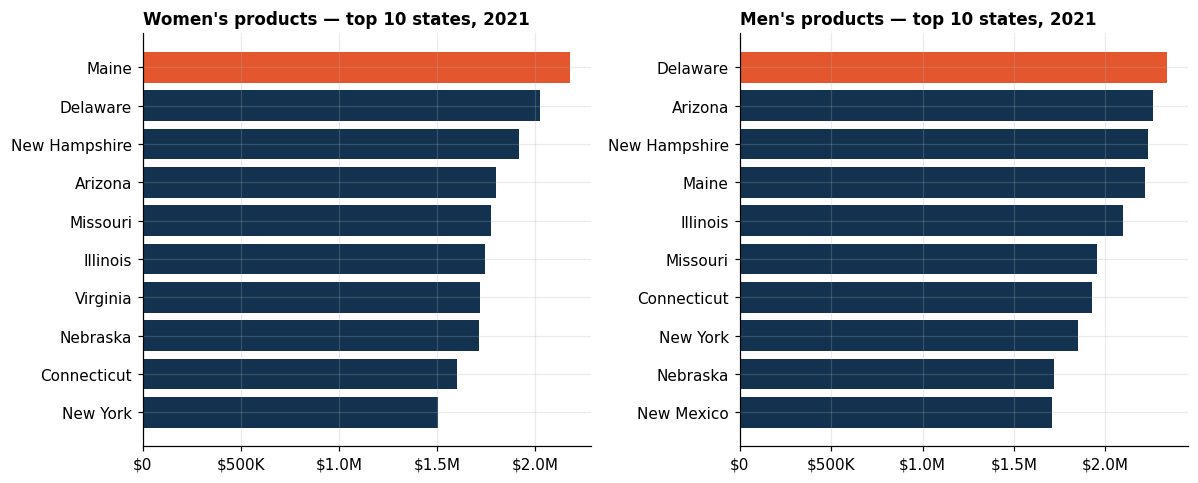

In [24]:
# Side-by-side view of the top 10 states in each segment
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=False)
for ax, data, label in [(axes[0], q2.head(10), "Women's"), (axes[1], q3.head(10), "Men's")]:
    colors = [ACCENT] + [NAVY] * (len(data) - 1)
    ax.barh(data.index[::-1], data["revenue"][::-1], color=colors[::-1])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(money))
    ax.set_title(f"{label} products — top 10 states, 2021", fontweight="bold", loc="left", fontsize=11)
save(fig, "q2_q3_top_states"); plt.show()

### Q4 — Which retailer purchased the most units in 2021? In 2020?

In [25]:
q4 = (df.pivot_table(index="RETAILER", columns="YEAR", values="UNITS_SOLD",
                     aggfunc="sum", fill_value=0)
        .sort_values(2021, ascending=False))
display(q4)

for yr in (2021, 2020):
    winner = q4[yr].idxmax()
    print(f"ANSWER Q4 ({yr}): {winner} — {q4.loc[winner, yr]:,.0f} units "
          f"({100 * q4.loc[winner, yr] / q4[yr].sum():.1f}% of units that year)")

YEAR,2020,2021
RETAILER,,
Foot Locker,0,1097410
West Gear,57334,269714
Sports Direct,18399,248296
Amazon,317930,205570
Kohl's,68686,136950
Walmart,0,58286
Unknown,0,298


ANSWER Q4 (2021): Foot Locker — 1,097,410 units (54.4% of units that year)
ANSWER Q4 (2020): Amazon — 317,930 units (68.8% of units that year)


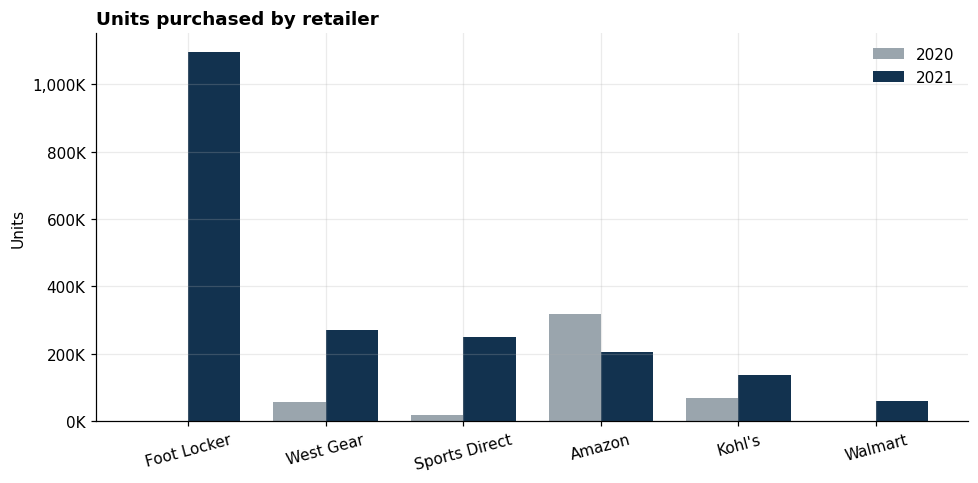

In [26]:
q4_plot = q4.drop(index="Unknown", errors="ignore")
fig, ax = plt.subplots(figsize=(9, 4.5))
idx = np.arange(len(q4_plot)); w = 0.38
ax.bar(idx - w/2, q4_plot[2020], w, label="2020", color=GREY)
ax.bar(idx + w/2, q4_plot[2021], w, label="2021", color=NAVY)
ax.set_xticks(idx); ax.set_xticklabels(q4_plot.index, rotation=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e3:,.0f}K"))
ax.set_title("Units purchased by retailer", fontweight="bold", loc="left")
ax.set_ylabel("Units")
ax.legend(frameon=False)
save(fig, "q4_retailer_units"); plt.show()

---
## 10. Insights and Trends

Five lines of analysis beyond the VP's questions.

### 10.1 Revenue grew 4x — but almost all of it came from new distribution, not from existing partners

Total revenue moved from $24.2M to $95.9M. Splitting that growth by whether a retailer traded in
both years separates *market expansion* from *underlying demand*.

In [27]:
years_active = df.groupby("RETAILER")["YEAR"].nunique()
existing = years_active[years_active == 2].index
new_2021 = years_active[years_active == 1].index

by_ret = df.pivot_table(index="RETAILER", columns="YEAR", values="TOTAL_SALES",
                        aggfunc="sum", fill_value=0)
by_ret["growth_$"] = by_ret[2021] - by_ret[2020]
by_ret["growth_%"] = np.where(by_ret[2020] > 0,
                              100 * by_ret["growth_$"] / by_ret[2020], np.nan)
by_ret["status"] = np.where(by_ret.index.isin(existing), "Both years", "New in 2021")
display(by_ret.sort_values("growth_$", ascending=False))

new_rev = by_ret.loc[by_ret["status"] == "New in 2021", 2021].sum()
lfl_growth = by_ret.loc[by_ret["status"] == "Both years", "growth_$"].sum()
total_growth = df_2021["TOTAL_SALES"].sum() - df[df.YEAR == 2020]["TOTAL_SALES"].sum()
print(f"\nTotal growth 2020->2021:        ${total_growth:,.0f}")
print(f"  from retailers new in 2021:   ${new_rev:,.0f}  ({100*new_rev/total_growth:.0f}%)")
print(f"  from existing retailers:      ${lfl_growth:,.0f}  ({100*lfl_growth/total_growth:.0f}%)")

YEAR,2020,2021,growth_$,growth_%,status
RETAILER,,,,,
Foot Locker,0.00,"53,646,425.00","53,646,425.00",NaN,New in 2021
Sports Direct,"901,235.00","11,639,054.00","10,737,819.00","1,191.46",Both years
West Gear,"2,179,209.00","10,648,564.00","8,469,355.00",388.64,Both years
Kohl's,"3,618,731.00","7,234,082.00","3,615,351.00",99.91,Both years
Walmart,0.00,"2,256,523.00","2,256,523.00",NaN,New in 2021
Unknown,0.00,"17,880.00","17,880.00",NaN,New in 2021
Amazon,"17,538,150.00","10,487,475.00","-7,050,675.00",-40.20,Both years



Total growth 2020->2021:        $71,692,678
  from retailers new in 2021:   $55,920,828  (78%)
  from existing retailers:      $15,771,850  (22%)


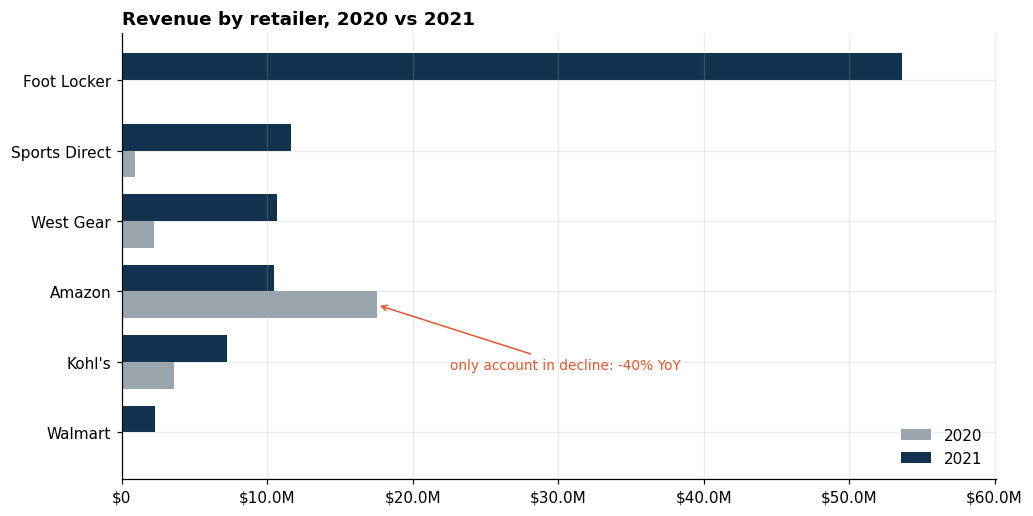

In [28]:
plot_df = by_ret.drop(index="Unknown", errors="ignore").sort_values(2021)
y = np.arange(len(plot_df)); h = 0.38

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.barh(y - h/2, plot_df[2020], h, color=GREY, label="2020")
ax.barh(y + h/2, plot_df[2021], h, color=NAVY, label="2021")
ax.set_yticks(y); ax.set_yticklabels(plot_df.index)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(money))
ax.set_title("Revenue by retailer, 2020 vs 2021", fontweight="bold", loc="left")
ax.legend(frameon=False, loc="lower right")
ax.set_xlim(0, plot_df[2021].max() * 1.12)

# Call out the one account that went backwards
amz = plot_df.index.get_loc("Amazon")
ax.annotate("only account in decline: -40% YoY",
            xy=(plot_df.loc["Amazon", 2020], amz - h/2),
            xytext=(plot_df[2021].max() * 0.42, amz - 1.1),
            fontsize=9, color=ACCENT,
            arrowprops=dict(arrowstyle="->", color=ACCENT))
save(fig, "insight_retailer_growth"); plt.show()

**Insight.** Two of the six retailers — Foot Locker and Walmart — had no 2020 activity at all
and together delivered $55.9M in 2021. Foot Locker alone is 56% of 2021 revenue.

**But the like-for-like picture is uneven.** Sports Direct ($0.9M → $11.6M) and West Gear
($2.2M → $10.6M) scaled dramatically, while **Amazon declined 40%** ($17.5M → $10.5M) — the only
partner to shrink, and it was the largest account in 2020. That decline is masked by headline
growth and deserves a direct account review.

### 10.2 Online is now the largest channel *and* the most profitable one

In [29]:
channel = (df.groupby(["YEAR", "SALES_METHOD"])
             .agg(revenue=("TOTAL_SALES", "sum"),
                  units=("UNITS_SOLD", "sum"),
                  profit=("OPERATING_PROFIT", "sum"))
             .reset_index())
channel["margin_%"] = 100 * channel["profit"] / channel["revenue"]
channel["share_%"] = 100 * channel["revenue"] / channel.groupby("YEAR")["revenue"].transform("sum")
display(channel.pivot(index="SALES_METHOD", columns="YEAR",
                      values=["revenue", "share_%", "margin_%"]))

revenue               share_%       margin_%      
YEAR                  2020          2021    2020  2021     2020  2021
SALES_METHOD                                                         
In-store      9,390,300.00 26,274,075.00   38.74 27.39    33.65 36.54
Online        4,519,966.00 40,446,456.00   18.65 42.16    46.83 43.11
Outlet       10,327,059.00 29,209,472.00   42.61 30.45    36.21 38.25

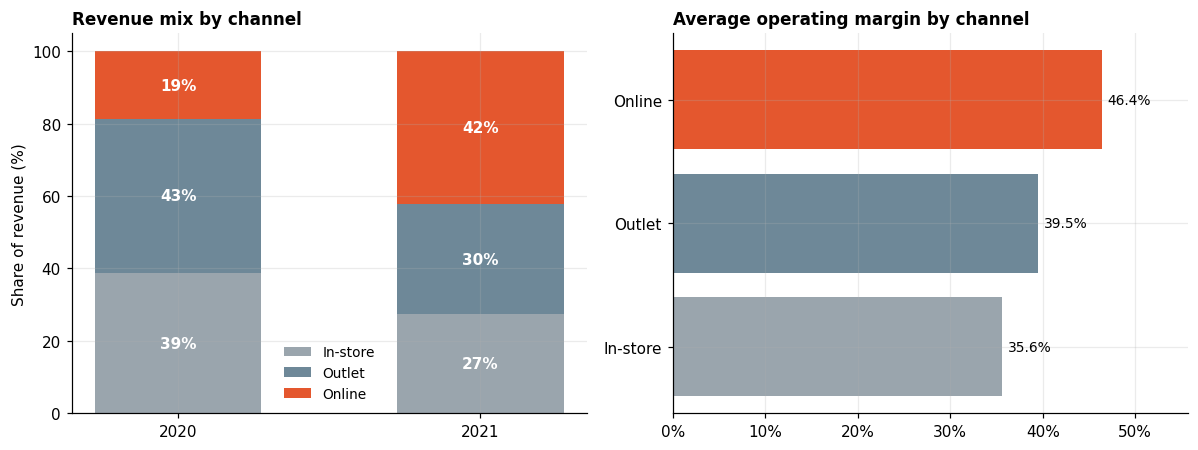

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
piv = channel.pivot(index="YEAR", columns="SALES_METHOD", values="share_%")
bottom = np.zeros(len(piv))
for i, m in enumerate(["In-store", "Outlet", "Online"]):
    axes[0].bar(piv.index.astype(str), piv[m], 0.55, bottom=bottom,
                label=m, color=[GREY, "#6E8898", ACCENT][i])
    for x, (b, v) in enumerate(zip(bottom, piv[m])):
        axes[0].text(x, b + v/2, f"{v:.0f}%", ha="center", va="center",
                     color="white", fontweight="bold", fontsize=10)
    bottom += piv[m].values
axes[0].set_title("Revenue mix by channel", fontweight="bold", loc="left", fontsize=11)
axes[0].set_ylabel("Share of revenue (%)"); axes[0].legend(frameon=False, fontsize=9)

marg = df.groupby("SALES_METHOD")["OPERATING_MARGIN"].mean().sort_values() * 100
axes[1].barh(marg.index, marg.values, color=[GREY, "#6E8898", ACCENT])
axes[1].set_title("Average operating margin by channel", fontweight="bold", loc="left", fontsize=11)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
for i, v in enumerate(marg.values):
    axes[1].text(v + 0.6, i, f"{v:.1f}%", va="center", fontsize=9)
axes[1].set_xlim(0, marg.max() * 1.2)
save(fig, "insight_channel_mix"); plt.show()

**Insight.** Online went from 19% of revenue in 2020 to 42% in 2021 — a $35.9M swing — and it
carries the **highest operating margin of the three channels (46.4%, versus 39.5% Outlet and 35.6%
In-store)**. This is the rare case where the fastest-growing channel is also the most profitable
one. Mix shift alone lifted the company margin from 37.2% to 39.8%.

### 10.3 Seasonality inverted between the two years

YEAR,2020,2021
Jan,"2,312,746.00","7,432,021.00"
Feb,"2,140,813.00","6,123,040.00"
Mar,"2,474,202.00","5,220,782.00"
Apr,"3,193,081.00","6,498,339.00"
May,"2,164,764.00","8,577,721.00"
Jun,"1,084,194.00","8,718,953.00"
Jul,"2,182,388.00","10,368,031.00"
Aug,"2,641,630.00","9,651,596.00"
Sep,"2,367,686.00","8,037,898.00"
Oct,"1,428,569.00","7,110,189.00"


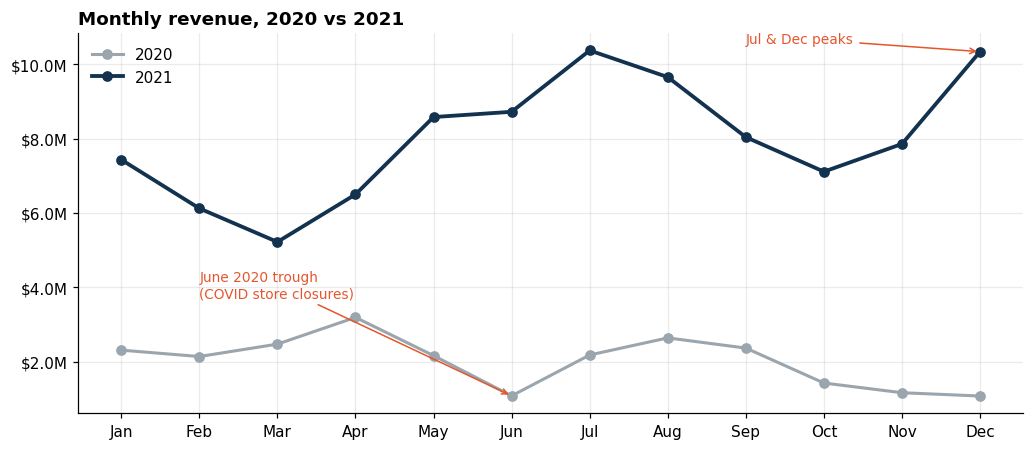

In [31]:
monthly = (df.groupby(["YEAR", "MONTH"])["TOTAL_SALES"].sum().unstack(0))
monthly.index = [pd.Timestamp(2021, m, 1).strftime("%b") for m in monthly.index]
display(monthly)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(monthly.index, monthly[2020], marker="o", color=GREY, lw=2, label="2020")
ax.plot(monthly.index, monthly[2021], marker="o", color=NAVY, lw=2.5, label="2021")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(money))
ax.set_title("Monthly revenue, 2020 vs 2021", fontweight="bold", loc="left")
ax.legend(frameon=False)
ax.annotate("June 2020 trough\n(COVID store closures)", xy=("Jun", monthly.loc["Jun", 2020]),
            xytext=("Feb", monthly[2021].max()*0.36), fontsize=9, color=ACCENT,
            arrowprops=dict(arrowstyle="->", color=ACCENT))
ax.annotate("Jul & Dec peaks", xy=("Dec", monthly.loc["Dec", 2021]),
            xytext=("Sep", monthly[2021].max()*1.02), fontsize=9, color=ACCENT,
            arrowprops=dict(arrowstyle="->", color=ACCENT))
save(fig, "insight_seasonality"); plt.show()

**Insight.** 2020 peaked in April and bottomed in June — the shape of pandemic disruption, not
of consumer demand. 2021 shows a normal retail rhythm: a summer peak in July ($10.4M) and a holiday
peak in December ($10.3M), with a March trough. **56% of 2021 revenue landed in the second half of
the year**, so 2020 should not be used as the planning baseline for inventory or promotional
calendars — 2021 should.

### 10.4 Revenue is dangerously concentrated in one partner

In [32]:
conc = (df_2021.groupby("RETAILER")
        .agg(revenue=("TOTAL_SALES", "sum"), units=("UNITS_SOLD", "sum"),
             states=("STATE", "nunique"), orders=("ORDER_ID", "count")))
conc["revenue_share_%"] = 100 * conc["revenue"] / conc["revenue"].sum()
conc["revenue_per_state"] = conc["revenue"] / conc["states"]
display(conc.sort_values("revenue", ascending=False))

top1 = conc["revenue_share_%"].max()
top2 = conc["revenue_share_%"].nlargest(2).sum()
print(f"\nTop retailer = {top1:.1f}% of 2021 revenue; top two = {top2:.1f}%")

,revenue,units,states,orders,revenue_share_%,revenue_per_state
RETAILER,,,,,,
Foot Locker,"53,646,425.00",1097410,33,2637,55.92,"1,625,649.24"
Sports Direct,"11,639,054.00",248296,23,1896,12.13,"506,045.83"
West Gear,"10,648,564.00",269714,21,2014,11.10,"507,074.48"
Amazon,"10,487,475.00",205570,5,419,10.93,"2,097,495.00"
Kohl's,"7,234,082.00",136950,10,636,7.54,"723,408.20"
Walmart,"2,256,523.00",58286,6,743,2.35,"376,087.17"
Unknown,"17,880.00",298,1,1,0.02,"17,880.00"



Top retailer = 55.9% of 2021 revenue; top two = 68.1%


**Insight.** Foot Locker is 56% of 2021 revenue across 33 states. That is a single point of
failure: losing or renegotiating that one account would move more revenue than the other five
partners combined. Walmart, by contrast, is only 6 states and $2.3M — the least developed of the
national partners despite the largest store footprint in the country. That gap is the clearest
white-space opportunity in the data.

### 10.5 Geography: the top states are footprint artifacts, not market size

In [33]:
state_2021 = (df_2021.groupby(["STATE", "REGION"])
              .agg(revenue=("TOTAL_SALES", "sum"), units=("UNITS_SOLD", "sum"),
                   retailers=("RETAILER", "nunique"))
              .reset_index().sort_values("revenue", ascending=False))
display(state_2021.head(12))

region = (df.groupby(["YEAR", "REGION"])
          .agg(revenue=("TOTAL_SALES", "sum"), profit=("OPERATING_PROFIT", "sum")))
region["margin_%"] = 100 * region["profit"] / region["revenue"]
display(region.unstack(0))

,STATE,REGION,revenue,units,retailers
18,Maine,Northeast,"4,393,491.00",78073,2
7,Delaware,Northeast,"4,357,875.00",86970,2
28,New Hampshire,Northeast,"4,151,000.00",84995,2
2,Arizona,West,"4,059,925.00",68315,2
12,Illinois,Midwest,"3,836,715.00",75943,2
24,Missouri,Midwest,"3,723,522.00",57888,2
6,Connecticut,Northeast,"3,526,724.00",65546,2
26,Nebraska,Midwest,"3,431,406.00",69539,2
46,Virginia,Southeast,"3,420,809.00",78222,2
31,New York,Northeast,"3,352,325.00",84427,3


revenue                     profit               margin_%      
YEAR              2020          2021         2020          2021     2020  2021
REGION                                                                        
Midwest   6,634,299.00 24,805,883.00 2,465,912.43  9,645,636.75    37.17 38.88
Northeast 7,094,424.00 31,742,464.00 2,498,795.84 12,251,670.99    35.22 38.60
South     1,281,362.00  9,044,277.00   423,942.39  4,234,589.58    33.09 46.82
Southeast 5,358,073.00  9,368,116.00 2,010,834.02  4,182,880.21    37.53 44.65
Unknown            NaN     17,880.00          NaN      7,509.60      NaN 42.00
West      3,869,167.00 20,951,383.00 1,616,020.40  7,887,479.72    41.77 37.65

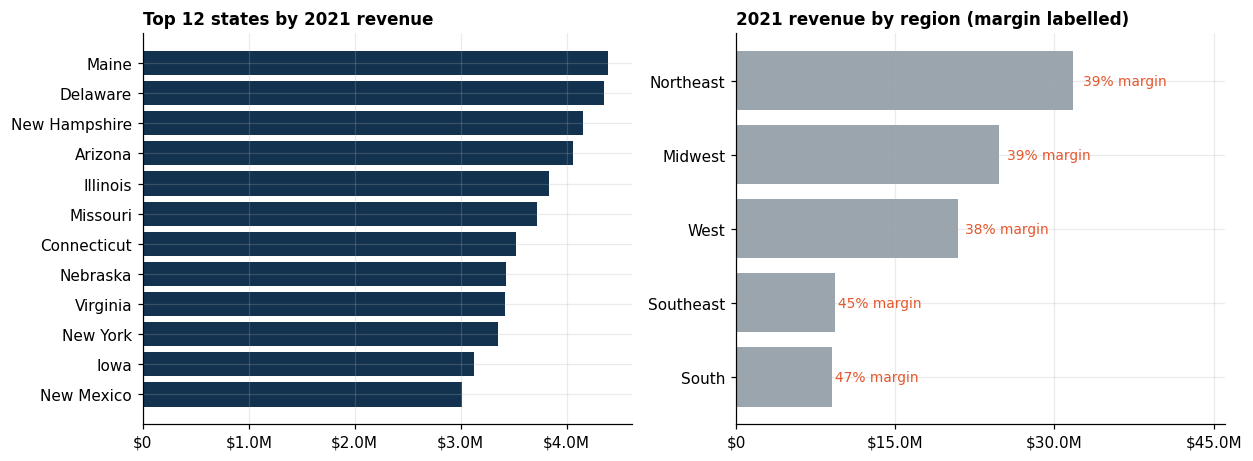

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
top12 = state_2021.head(12).iloc[::-1]
axes[0].barh(top12["STATE"], top12["revenue"], color=NAVY)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(money))
axes[0].set_title("Top 12 states by 2021 revenue", fontweight="bold", loc="left", fontsize=11)

reg21 = (region.xs(2021, level="YEAR")
               .drop(index="Unknown", errors="ignore")
               .sort_values("revenue"))
axes[1].barh(reg21.index, reg21["revenue"], color=GREY)
for i, (r, row) in enumerate(reg21.iterrows()):
    axes[1].text(row["revenue"] * 1.03, i, f"{row['margin_%']:.0f}% margin",
                 va="center", fontsize=9, color=ACCENT)
axes[1].set_xlim(0, reg21["revenue"].max() * 1.45)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(money))
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(4))
axes[1].set_title("2021 revenue by region (margin labelled)", fontweight="bold",
                  loc="left", fontsize=11)
save(fig, "insight_geography"); plt.show()

**Insight.** The top states are Maine, Delaware, and New Hampshire — three of the smallest
states in the country. They rank first because of *who sells there*, not because of market size:
Maine's total is essentially one Amazon location, and Delaware's is one Foot Locker. Two
consequences for leadership:

* State rankings should be read as **account performance**, not as market attractiveness. A
  per-capita or per-location view would tell a very different story.
* The **South and Southeast carry the highest operating margins (46.8% and 44.7%)** but only
  $9.0M and $9.4M of revenue each — the lowest of the five regions. Margin-accretive growth is
  available in exactly the regions where RUSH is least present.

---
## 11. Findings and Recommendations

**What the data says**

1. **2021 was a distribution story, not a demand story.** —
Revenue quadrupled to $95.9M, but 78% of the growth came from two retailers that did not trade with RUSH in 2020.

2. **Men's Street Footwear is the flagship** — $22.7M, 23.7% of revenue, the #1 category in every
   channel.
3. **Online is now the largest and most profitable channel** — 42% of revenue at a 46.4% operating
   margin.
4. **Amazon is shrinking** — down 40% year over year, the only partner in decline, and it was the
   #1 account in 2020.
5. **Concentration risk is real** — Foot Locker alone is 56% of revenue.

**Recommended actions**

| Priority | Action | Rationale |
|---|---|---|
| 1 | Open an account review with Amazon | $7.1M of revenue lost year over year, against a backdrop of company-wide growth |
| 2 | Shift mix further toward Online | Highest margin channel; every point of mix shift is margin-accretive |
| 3 | Expand Walmart beyond 6 states | Largest physical footprint, smallest RUSH revenue — clearest white space |
| 4 | Plan 2022 inventory on the 2021 curve | 2020 seasonality was distorted by COVID; 2021 shows July/December peaks |
| 5 | Fix the `RETAILER_ID` scheme at source | The key is not unique — 4 collisions today, more as the network grows |

**Caveats on the analysis**

* Two years of data is not a trend line; 2020 is a pandemic year and a poor baseline.
* $2.26M of 2021 revenue sits under an ambiguous retailer key (see Appendix). It does not change
  any answer above, but Walmart/West Gear splits should be treated as approximate.
* Revenue is derived as price x units; no returns, discounts, or freight data are available.

---
## 12. Appendix — Sensitivity Check on the Ambiguous Retailer Key

Three `RETAILER_ID` values could belong to either Walmart or West Gear. Section 7 assigned them to
Walmart (the first matching row). This appendix re-runs Q4 under the opposite assumption to confirm
the answer is robust.

In [35]:
ambiguous = ["W00SARLI", "W00SFLOR", "W00STEHO"]
amb = df_2021[df_2021["RETAILER_ID"].isin(ambiguous)]
print(f"Ambiguous rows: {len(amb):,} | units {amb['UNITS_SOLD'].sum():,} | "
      f"revenue ${amb['TOTAL_SALES'].sum():,.0f} "
      f"({100*amb['TOTAL_SALES'].sum()/df_2021['TOTAL_SALES'].sum():.1f}% of 2021 revenue)")

alt = df_2021.copy()
alt.loc[alt["RETAILER_ID"].isin(ambiguous), "RETAILER"] = "West Gear"

comparison = pd.DataFrame({
    "assigned to Walmart": df_2021.groupby("RETAILER")["UNITS_SOLD"].sum(),
    "assigned to West Gear": alt.groupby("RETAILER")["UNITS_SOLD"].sum(),
}).fillna(0).sort_values("assigned to Walmart", ascending=False)
display(comparison)

print("\nQ4 2021 winner under assumption A:", comparison['assigned to Walmart'].idxmax())
print("Q4 2021 winner under assumption B:", comparison['assigned to West Gear'].idxmax())
print("=> The answer to Q4 is unchanged under either assumption.")

Ambiguous rows: 567 | units 46,016 | revenue $1,763,145 (1.8% of 2021 revenue)


,assigned to Walmart,assigned to West Gear
RETAILER,,
Foot Locker,1097410,1097410
West Gear,269714,315730
Sports Direct,248296,248296
Amazon,205570,205570
Kohl's,136950,136950
Walmart,58286,12270
Unknown,298,298



Q4 2021 winner under assumption A: Foot Locker
Q4 2021 winner under assumption B: Foot Locker
=> The answer to Q4 is unchanged under either assumption.


In [36]:
# Export the cleaned dataset so the presentation numbers are reproducible
df.to_csv(OUT_DIR / "rush_clean_orders.csv", index=False)
print(f"Wrote {OUT_DIR / 'rush_clean_orders.csv'} — {len(df):,} rows")
print("Figures written to figures/:", sorted(p.name for p in FIG_DIR.glob('*.png')))

Wrote outputs/rush_clean_orders.csv — 9,648 rows
Figures written to figures/: ['insight_channel_mix.png', 'insight_geography.png', 'insight_retailer_growth.png', 'insight_seasonality.png', 'q1_product_revenue.png', 'q2_q3_top_states.png', 'q4_retailer_units.png']
